ML PROJECT ON USED SMARTPHONE PR

This project focuses on predicting the resale price of used smartphones using machine learning techniques. Various factors such as brand, RAM, storage, battery health, phone condition, and age are analyzed to understand their impact on resale value. Exploratory Data Analysis (EDA) is performed to identify patterns and trends, and Multiple Linear Regression and Polynomial Regression models are used to predict smartphone prices accurately.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("c:\\DATASCIENCE\\assignment\\used_phone_price_prediction_1M.csv")
df.head(5)

,brand,model,release_year,ram_gb,storage_gb,screen_size_inches,battery_capacity,processor_score,camera_score,os_type,...,body_damage,repair_history,water_damage,city_tier,seller_type,warranty_remaining_months,box_available,charger_available,market_demand_score,resale_price
0,Realme,Realme GT,2025,4,256,6.93,4130,47,100,Android,...,0,0,0,Tier1,Individual,11,1,1,99,47891.46
1,Samsung,Galaxy S21,2024,16,64,6.29,5558,81,67,Android,...,0,0,0,Tier3,Store,8,1,0,64,17663.21
2,Apple,iPhone 11,2022,4,128,5.52,5945,59,67,iOS,...,0,0,0,Tier1,Individual,0,0,1,68,67268.20
3,Google,Pixel 6,2024,16,512,5.99,5767,84,57,Android,...,0,0,1,Tier1,Store,11,1,1,50,12626.26
4,Google,Pixel 7,2021,4,128,6.59,5336,98,44,Android,...,0,0,0,Tier3,Store,24,1,1,66,20662.25


In [4]:
df.isnull().sum()

brand                        0
model                        0
release_year                 0
ram_gb                       0
storage_gb                   0
screen_size_inches           0
battery_capacity             0
processor_score              0
camera_score                 0
os_type                      0
has_5g                       0
original_price               0
purchase_year                0
age_months                   0
usage_hours_per_day          0
condition                    0
battery_health               0
screen_cracked               0
body_damage                  0
repair_history               0
water_damage                 0
city_tier                    0
seller_type                  0
warranty_remaining_months    0
box_available                0
charger_available            0
market_demand_score          0
resale_price                 0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [11]:
# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 29 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   brand                      1000000 non-null  object 
 1   model                      1000000 non-null  object 
 2   release_year               1000000 non-null  int64  
 3   ram_gb                     1000000 non-null  int64  
 4   storage_gb                 1000000 non-null  int64  
 5   screen_size_inches         1000000 non-null  float64
 6   battery_capacity           1000000 non-null  int64  
 7   processor_score            1000000 non-null  int64  
 8   camera_score               1000000 non-null  int64  
 9   os_type                    1000000 non-null  object 
 10  has_5g                     1000000 non-null  int64  
 11  original_price             1000000 non-null  int64  
 12  purchase_year              1000000 non-null  int64  
 13  age_months   

In [13]:
df['depreciation_rate'] = (
    (df['original_price'] - df['resale_price'])
    / df['original_price']
)

In [15]:
df['age_years'] = df['age_months'] / 12

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['brand','model','os_type',
            'condition','city_tier',
            'seller_type']:
    df[col] = le.fit_transform(df[col])

In [31]:
# Independent variables (all columns except resale_price)
X = df.drop('resale_price', axis=1)

# Dependent variable (target)
y = df['resale_price']

print("X Shape:", X.shape)
print("y Shape:", y.shape)


X Shape: (1000000, 29)
y Shape: (1000000,)


In [33]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [35]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train,y_train)

LinearRegression()

In [37]:
y_pred = lr.predict(X_test)

In [39]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",mean_squared_error(y_test,y_pred,squared=False))
print("R2:",r2_score(y_test,y_pred))

MAE: 4106.421048401132
MSE: 36006737.915360086
RMSE: 6000.561466676271
R2: 0.8710742522572422


In [40]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

In [41]:
from sklearn.linear_model import LinearRegression

poly_model = LinearRegression()

poly_model.fit(
    X_poly_train,
    y_train
)

LinearRegression()

In [44]:
poly_pred = poly_model.predict(
    X_poly_test
)

In [46]:
print("MAE:",mean_absolute_error(y_test,poly_pred))
print("RMSE:",mean_squared_error(
    y_test,
    poly_pred,
    squared=False
))
print("R2:",r2_score(y_test,poly_pred))

MAE: 1.982205809554216e-09
RMSE: 2.538259368436589e-09
R2: 1.0


Answer: 2 (143120 listings)


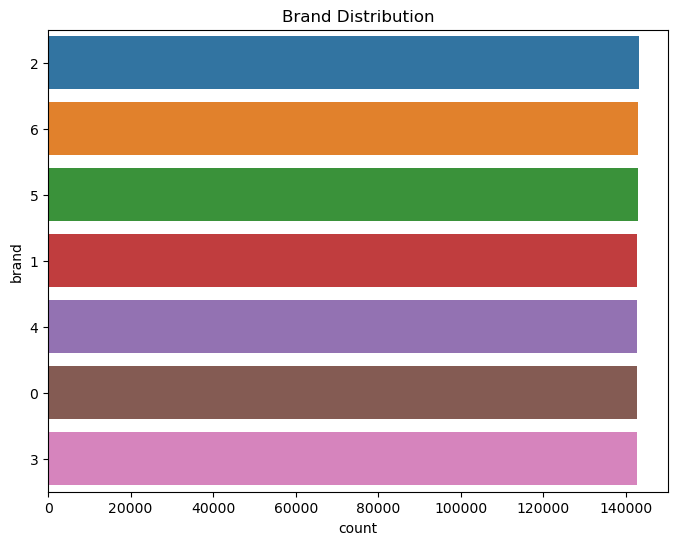

In [69]:
# Q1. Which smartphone brand has the highest number of listings?
brand_counts = df['brand'].value_counts()

answer = brand_counts.idxmax()
count = brand_counts.max()

print(f"Answer: {answer} ({count} listings)")

plt.figure(figsize=(8,6))
sns.countplot(
    y='brand',
    data=df,
    order=brand_counts.index
)
plt.title("Brand Distribution")
plt.show()

Answer: 22598.0


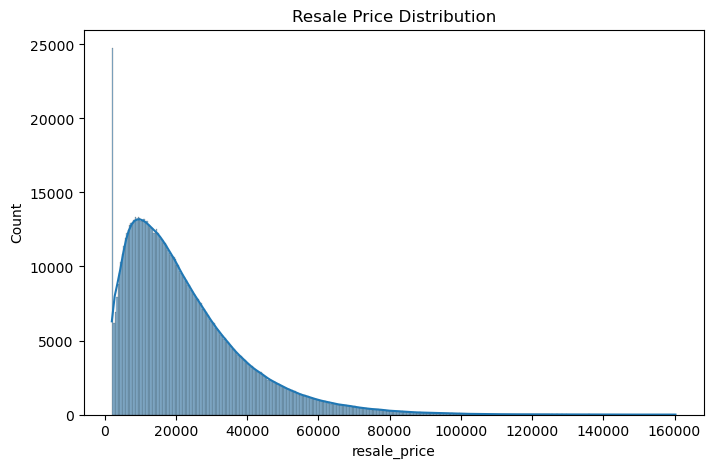

In [70]:
# Q2. What is the average resale price of used phones?
avg_price = df['resale_price'].mean()

print("Answer:", round(avg_price,2))

plt.figure(figsize=(8,5))
sns.histplot(df['resale_price'], kde=True)
plt.title("Resale Price Distribution")
plt.show()

Answer: 2


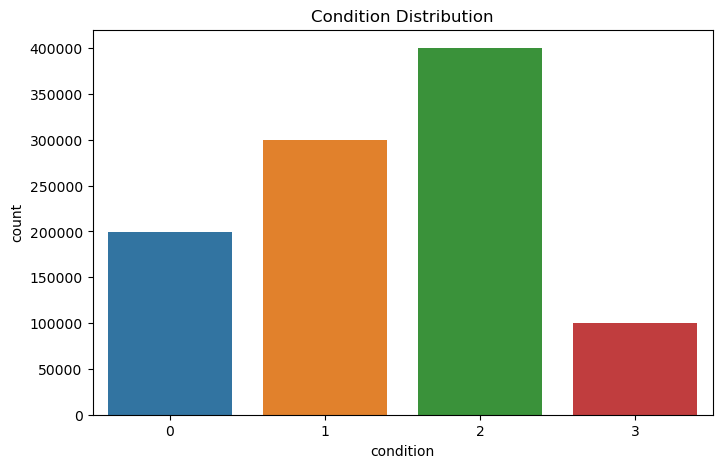

In [71]:
# Q3. Which phone condition category appears most frequently?
condition_counts = df['condition'].value_counts()

print("Answer:", condition_counts.idxmax())

plt.figure(figsize=(8,5))
sns.countplot(x='condition', data=df)
plt.title("Condition Distribution")
plt.show()

Answer: 77.5079


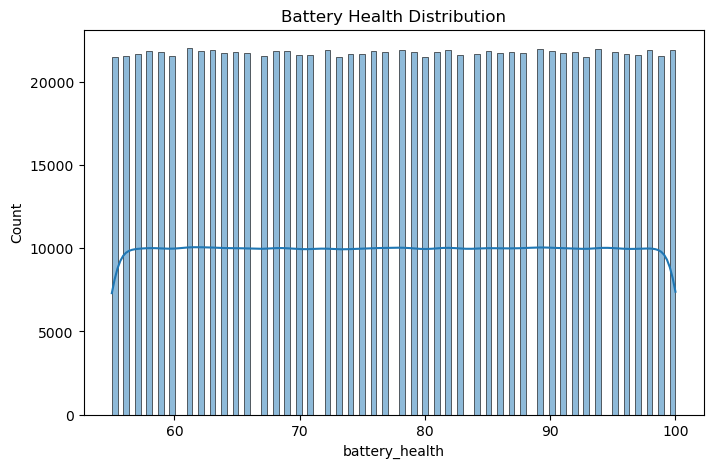

In [73]:
# Q4. What is the average battery health across all devices
avg_battery = df['battery_health'].mean()

print("Answer:", round(avg_battery,5))

plt.figure(figsize=(8,5))
sns.histplot(df['battery_health'], kde=True)
plt.title("Battery Health Distribution")
plt.show()

1    80.0063
0    19.9937
Name: has_5g, dtype: float64


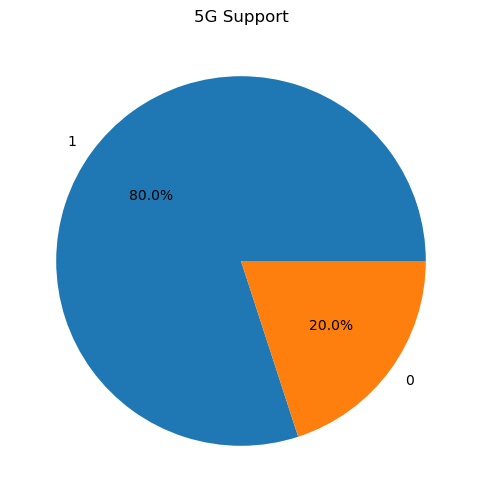

In [74]:
# Q5. What percentage of phones support 5G?
fiveg_percent = (
    df['has_5g']
    .value_counts(normalize=True)
    * 100
)

print(fiveg_percent)

plt.figure(figsize=(6,6))
plt.pie(
    fiveg_percent,
    labels=fiveg_percent.index,
    autopct='%1.1f%%'
)
plt.title("5G Support")
plt.show()

Answer:
brand
0    26799.983454
4    24298.011150
1    23635.793967
2    22458.514789
6    20835.686344
Name: resale_price, dtype: float64


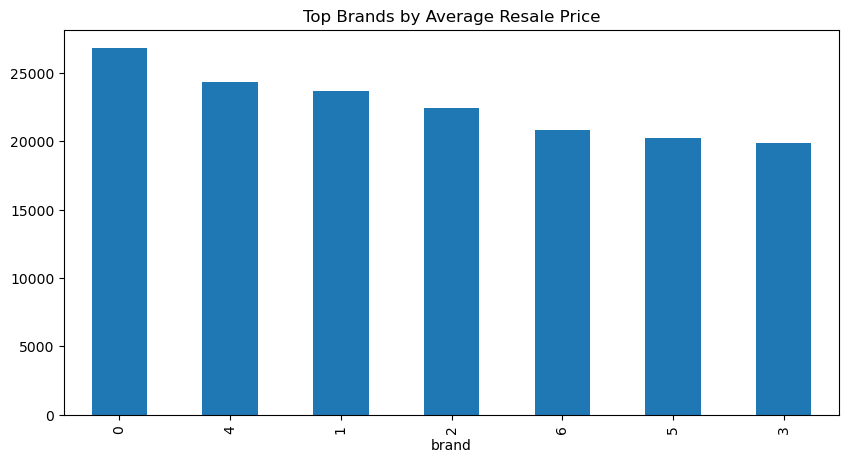

In [76]:
# Q6. Which brand has the highest average resale price?
brand_price = (
    df.groupby('brand')['resale_price']
    .mean()
    .sort_values(ascending=False)
)

print("Answer:")
print(brand_price.head())

brand_price.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Brands by Average Resale Price")
plt.show()

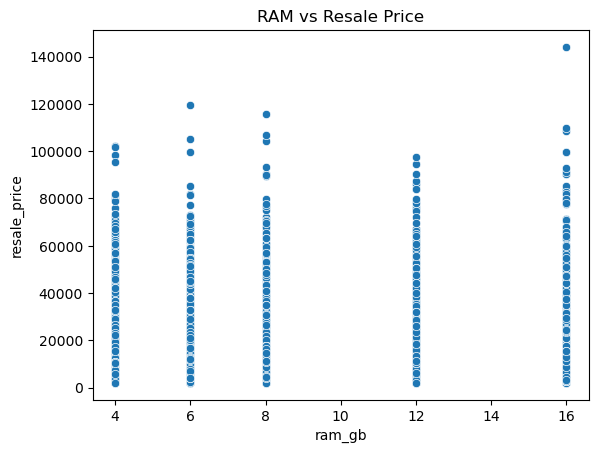

In [77]:
# Q7. How does RAM affect resale price?
sns.scatterplot(
    x='ram_gb',
    y='resale_price',
    data=df.sample(5000)
)

plt.title("RAM vs Resale Price")
plt.show()

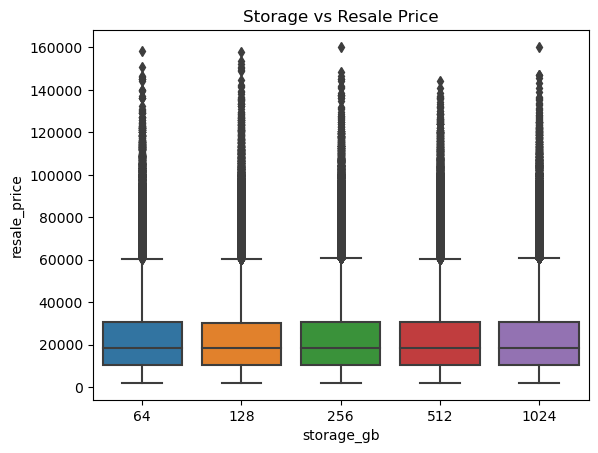

In [82]:
# Q8. How does storage capacity affect resale price?
sns.boxplot(
    x='storage_gb',
    y='resale_price',
    data=df
)

plt.title("Storage vs Resale Price")
plt.show()

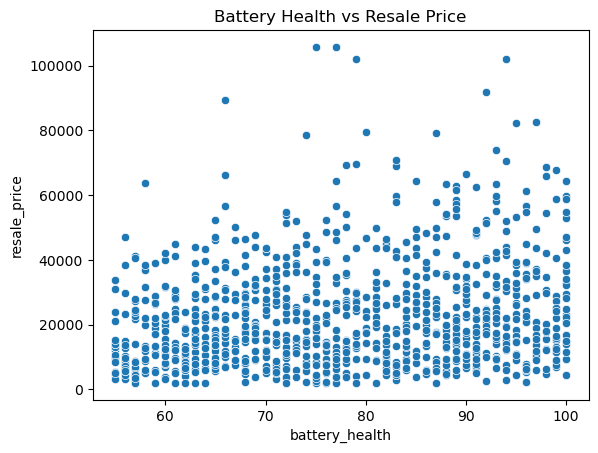

In [79]:
# 9 Does battery health significantly impact resale price?
sns.scatterplot(
    x='battery_health',
    y='resale_price',
    data=df.sample(1000)
)

plt.title("Battery Health vs Resale Price")
plt.show()

screen_cracked
0    23042.80076
1    17481.21447
Name: resale_price, dtype: float64


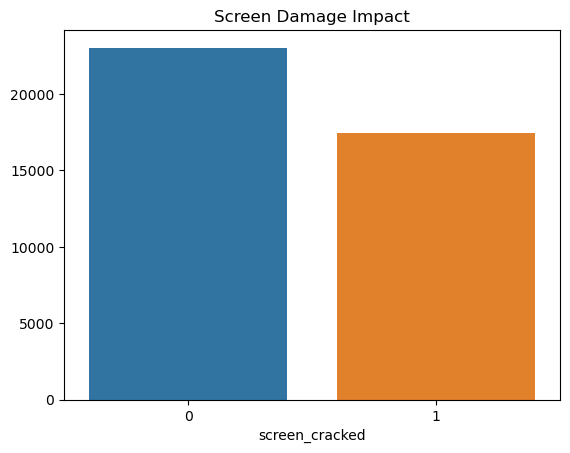

In [80]:
# How much does screen damage reduce resale value?
damage = (
    df.groupby('screen_cracked')
    ['resale_price']
    .mean()
)

print(damage)

sns.barplot(
    x=damage.index,
    y=damage.values
)

plt.title("Screen Damage Impact")
plt.show()

repair_history
0    22867.364374
1    21077.899401
Name: resale_price, dtype: float64


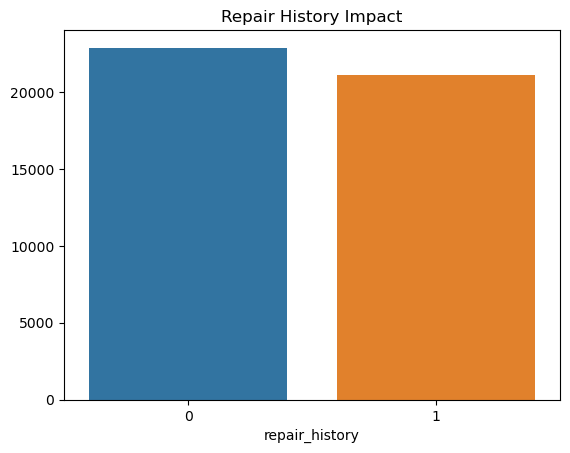

In [81]:
# . Do phones with repair history sell for lower prices
repair = (
    df.groupby('repair_history')
    ['resale_price']
    .mean()
)

print(repair)

sns.barplot(
    x=repair.index,
    y=repair.values
)

plt.title("Repair History Impact")
plt.show()

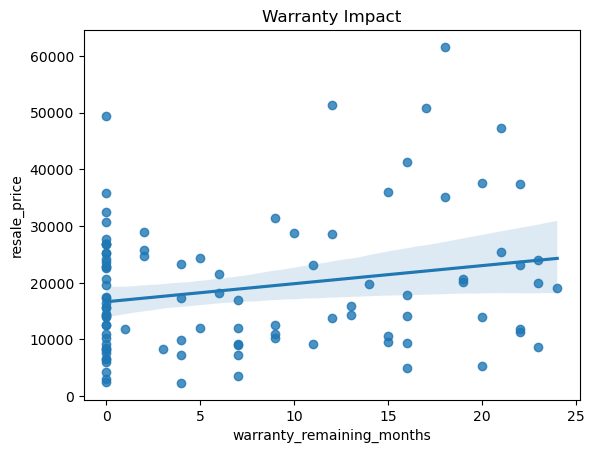

In [67]:
#  Does warranty significantly increase resale value?
sns.regplot(
    x='warranty_remaining_months',
    y='resale_price',
    data=df.sample(100)
)

plt.title("Warranty Impact")
plt.show()

CONCLUSION

The project successfully analyzed the factors affecting used smartphone prices and developed predictive models for resale price estimation. Features such as original price, battery health, age, RAM, and storage were found to have a significant impact on resale value. The results show that machine learning can be effectively used to predict smartphone prices and support better pricing decisions in the used mobile phone market.